# ECPM — 31 Cooling Model Analysis (Additive Curve Fit)

Systematically fits all **31 non-empty subsets** of 5 candidate feature variables
to the cooling component of the additive ECPM equation:

$$E_c = c_{c1}(T_{ext}-T_c)^+ + c_{c2}(T_{ext}-T_{int})^+\cdot\theta(T_{ext}-T_c)$$

where $\theta(T_{ext}-T_c) = 1$ if $T_{ext} > T_c$, else $0$.

Each model uses `scipy.optimize.curve_fit` with non-negative coefficient constraints,
fitted **exclusively on cooling-period days** ($T_{ext} > T_c$).

| Variable | Expression | Description |
|---|---|---|
| X1 | $T_{ext}$ | Exterior temperature |
| X2 | $T_{int}$ | Interior temperature |
| X3 | $(T_c - T_{ext})^+$ | Exterior temperature below $T_c$ |
| X4 | $(T_{int} - T_{ext})^+$ | Interior warmer than exterior |
| X5 | $(T_c - T_{int})^+$ | Interior temperature below $T_c$ |

Total combinations: $2^5 - 1 = \mathbf{31}$

> **Model selection:** AIC (lower = better). ΔAIC < 2 → comparable models → prefer fewer variables.
> **ASHRAE Guideline 14:** CV-RMSE ≤ 25 % and |NMBE| ≤ 5 %


## 0 · Setup

In [237]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from pathlib import Path

DATA_DIR  = Path("../Prepared_Data")
CPM_PARAM = Path("../CPM_Results/AllYears_Preprocessed_Method1")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

COLORS = {
    'weekday':    '#2271B5',
    'weekend':    '#E9672A',
    'actual_wd':  '#888888',
    'actual_we':  '#BBBBBB',
}

print('All packages loaded.')


All packages loaded.


## 1 · Load data

In [238]:
ENERGY_CSV    = DATA_DIR / 'KEPCO_AllYears_Preprocessed_Method1.csv'
CP_PARAMS_CSV = CPM_PARAM / 'KEPCO_Yearly_CPM_Parameters.csv'

df = pd.read_csv(ENERGY_CSV)
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.dropna(subset=['electricity_kWh', 'temp_external', 'temp_internal', 'is_weekend'])
df = df.sort_values('datetime').reset_index(drop=True)
df['is_weekend'] = df['is_weekend'].astype(int)
df['day_type']   = df['is_weekend'].map({0: 'weekday', 1: 'weekend'})

floor_area_m2 = (df['electricity_kWh'] * 1000 / df['EUI_Wh_m2']).median()

print(f'Total rows : {len(df)}')
print(f'Weekdays   : {(df["is_weekend"]==0).sum()}')
print(f'Weekends   : {(df["is_weekend"]==1).sum()}')
print(f'Date range : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Years      : {sorted(df["year"].unique())}')
print(f'Floor area : {floor_area_m2:.1f} m²')
df.head(3)


Total rows : 763
Weekdays   : 604
Weekends   : 159
Date range : 2020-04-17 → 2025-08-25
Years      : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Floor area : 5381.0 m²


,datetime,year,is_weekend,electricity_kWh,temp_external,temp_internal,EUI_Wh_m2,day_type
0,2020-04-17,2020,0,54.583333,12.902246,21.724062,10.143678,weekday
1,2020-04-19,2020,1,28.916667,12.943029,19.284050,5.373826,weekend
2,2020-04-21,2020,0,57.343750,8.183979,20.794250,10.656669,weekday


In [239]:
cp = pd.read_csv(CP_PARAMS_CSV)

# Normalise column names
for c in cp.columns:
    if c.lower() == 'year' and c != 'year':
        cp = cp.rename(columns={c: 'year'}); break

if 'Tc' not in cp.columns and 'tau_c' in cp.columns:
    cp = cp.rename(columns={'tau_c': 'Tc', 'tau_h': 'Th'})

cp['day_type'] = cp['day_type'].str.lower().str.strip().str.rstrip('s')
cp['year']     = cp['year'].astype(str)

print('cp_params loaded:')
print(cp[['year', 'day_type', 'Tc', 'Th', 'alpha']].to_string(index=False))


cp_params loaded:
year day_type        Tc        Th    alpha
2020  weekday 19.850957 15.717472 8.088002
2021  weekday 19.279155 16.050205 8.088256
2022  weekday 19.103497 15.605047 8.571796
2023  weekday 19.000000 17.471349 8.558636
2024  weekday 19.000000 18.000000 8.176988
2025  weekday 19.003527 14.920923 9.222514
2020  weekend 23.413117 17.999618 4.986828
2021  weekend 24.571534 17.565248 4.883707
2022  weekend 19.000000  8.005670 5.385289
2023  weekend 30.000000 18.000000 5.738792
2024  weekend 19.000000  9.092424 5.482651
2025  weekend 22.517239 14.891419 5.808324


## 1b · EDA — EUI vs Temperature Features

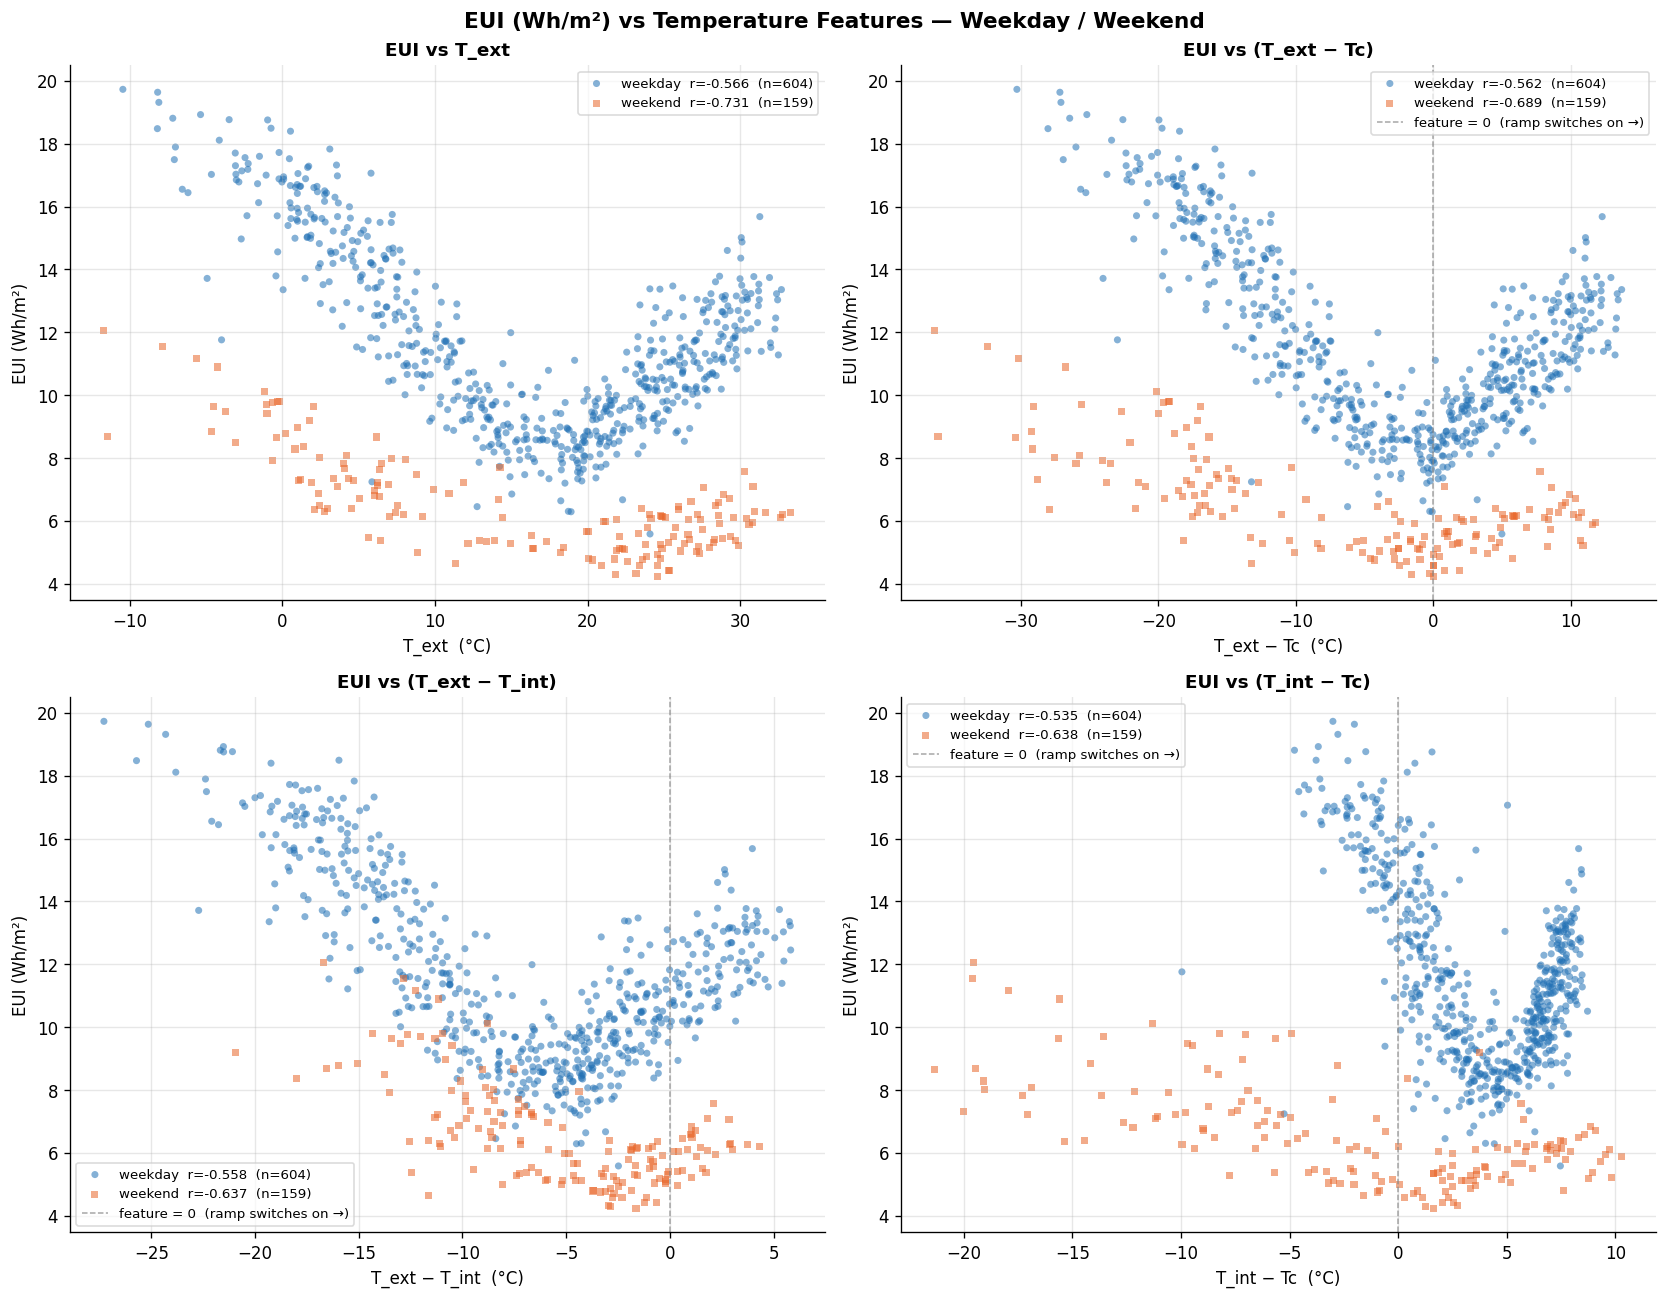

Saved: eui_vs_temp_features.png

Pearson r — EUI vs each temperature feature:


,Feature,day_type,n,Pearson_r,p_value
0,T_ext (°C),weekday,604,-0.5660,1.88e-52
1,T_ext (°C),weekend,159,-0.7313,7.06e-28
2,T_ext − Tc (°C),weekday,604,-0.5620,1.36e-51
3,T_ext − Tc (°C),weekend,159,-0.6893,9.69e-24
4,T_ext − T_int (°C),weekday,604,-0.5576,1.19e-50
5,T_ext − T_int (°C),weekend,159,-0.6366,1.92e-19
6,T_int − Tc (°C),weekday,604,-0.5355,4.03e-46
7,T_int − Tc (°C),weekend,159,-0.6376,1.60e-19


In [240]:
from scipy.stats import pearsonr

# ── Merge per-year Tc / Th into df to compute derived temperature features ────
cp_merge = cp[['year', 'day_type', 'Tc', 'Th']].copy()
cp_merge['year'] = cp_merge['year'].astype(int)

df_feat = df.merge(cp_merge, on=['year', 'day_type'], how='left')

# ── Derived features ──────────────────────────────────────────────────────────
df_feat['T_ext_minus_Tc']   = df_feat['temp_external'] - df_feat['Tc']
df_feat['T_ext_minus_Tint'] = df_feat['temp_external'] - df_feat['temp_internal']
df_feat['Tint_minus_Tc']    = df_feat['temp_internal'] - df_feat['Tc']

# ── Plot ───────────────────────────────────────────────────────────────────────
features = [
    ('temp_external',    'T_ext  (°C)',         'EUI vs T_ext'),
    ('T_ext_minus_Tc',   'T_ext − Tc  (°C)',    'EUI vs (T_ext − Tc)'),
    ('T_ext_minus_Tint', 'T_ext − T_int  (°C)', 'EUI vs (T_ext − T_int)'),
    ('Tint_minus_Tc',    'T_int − Tc  (°C)',    'EUI vs (T_int − Tc)'),
]

WD_COL = '#2271B5'
WE_COL = '#E9672A'

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('EUI (Wh/m²) vs Temperature Features — Weekday / Weekend',
             fontsize=13, fontweight='bold')

for ax, (col, xlabel, title) in zip(axes.flatten(), features):
    for dt, color, marker in [('weekday', WD_COL, 'o'), ('weekend', WE_COL, 's')]:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, _ = pearsonr(sub[col], sub['EUI_Wh_m2'])
        ax.scatter(sub[col], sub['EUI_Wh_m2'],
                   color=color, marker=marker, s=18, alpha=0.55,
                   edgecolors='none',
                   label=f'{dt}  r={r:+.3f}  (n={len(sub)})')

    # vertical reference at 0 for derived features
    if col != 'temp_external':
        ax.axvline(0, color='gray', lw=0.9, ls='--', alpha=0.7,
                   label='feature = 0  (ramp switches on →)')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('EUI (Wh/m²)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig('eui_vs_temp_features.png', bbox_inches='tight')
plt.show()
print('Saved: eui_vs_temp_features.png')

# ── Pearson r summary table ───────────────────────────────────────────────────
print('\nPearson r — EUI vs each temperature feature:')
rows_r = []
for col, xlabel, _ in features:
    for dt in ['weekday', 'weekend']:
        sub = df_feat[df_feat['day_type'] == dt].dropna(subset=[col, 'EUI_Wh_m2'])
        r, pval = pearsonr(sub[col], sub['EUI_Wh_m2'])
        rows_r.append({'Feature': xlabel, 'day_type': dt,
                        'n': len(sub), 'Pearson_r': round(r, 4),
                        'p_value': f'{pval:.2e}'})
display(pd.DataFrame(rows_r))


## 2 · Helper functions

In [241]:
def rplus(x):
    """Positive part operator: max(0, x)."""
    return np.maximum(x, 0)


def get_cp(year_key, day_type):
    """Return (Tc, Th, Eb_kWh) for a given year / day_type from cp_params."""
    if year_key == 'all':
        rows = cp[cp['day_type'] == day_type]
        if rows.empty:
            raise ValueError(f"No cp_params for day_type='{day_type}'")
        if 'n_samples' in rows.columns:
            w  = rows['n_samples'].values.astype(float)
            Tc = float(np.average(rows['Tc'].values,    weights=w))
            Th = float(np.average(rows['Th'].values,    weights=w))
            Eb = float(np.average(rows['alpha'].values, weights=w)) * floor_area_m2 / 1000
        else:
            Tc = float(rows['Tc'].mean())
            Th = float(rows['Th'].mean())
            Eb = float(rows['alpha'].mean()) * floor_area_m2 / 1000
        return Tc, Th, Eb
    row = cp[(cp['year'] == str(year_key)) & (cp['day_type'] == day_type)]
    if row.empty:
        raise ValueError(f"No cp_params for year='{year_key}', day_type='{day_type}'")
    return (float(row['Tc'].values[0]),
            float(row['Th'].values[0]),
            float(row['alpha'].values[0]) * floor_area_m2 / 1000)


def get_subset(df_full, year_key, day_type):
    """Filter dataframe by year and day_type."""
    sub = df_full.copy()
    if year_key != 'all':
        sub = sub[sub['year'] == int(year_key)]
    return sub[sub['day_type'] == day_type].reset_index(drop=True)


def compute_metrics(Ec_actual, Ec_pred, n_params):
    """Compute goodness-of-fit metrics for a cooling model."""
    n      = len(Ec_actual)
    r2     = r2_score(Ec_actual, Ec_pred)
    rmse   = np.sqrt(mean_squared_error(Ec_actual, Ec_pred))
    ssr    = np.sum((Ec_actual - Ec_pred) ** 2)
    cvrmse = rmse / (np.mean(Ec_actual) + 1e-12) * 100
    nmbe   = np.mean(Ec_pred - Ec_actual) / (np.mean(Ec_actual) + 1e-12) * 100
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(n - n_params - 1, 1)
    aic    = n * np.log(ssr / n + 1e-12) + 2 * n_params
    bic    = n * np.log(ssr / n + 1e-12) + n_params * np.log(n)
    return dict(R2=r2, Adj_R2=adj_r2, RMSE=rmse,
                CV_RMSE_pct=cvrmse, NMBE_pct=nmbe,
                AIC=aic, BIC=bic, n_params=n_params)


print('Helper functions defined.')


Helper functions defined.


## 3 · Cooling feature variables & 31 combinations

The five candidate variables cover the key temperature drivers of cooling energy.
All combinations of these five — from single-variable up to all-five — give $2^5-1 = 31$ models.

| Variable | Expression | Description |
|---|---|---|
| X1 | $T_{ext}$ | Exterior temperature |
| X2 | $T_{int}$ | Interior temperature |
| X3 | $(T_{ext} - Tc)^+$ | Exterior temperature below $T_c$ |
| X4 | $(T_{ext} - T_{int})^+$ | Interior warmer than exterior |
| X5 | $(T_{int} - T_c)^+$ | Interior temperature below $T_c$ |


In [242]:
# ── Feature registry ─────────────────────────────────────────────────────────
FEATURE_LABELS = ['Text', 'Tint', 'Text-Tc', 'Text-Tint', 'Tint-Tc']
N_FEATURES     = len(FEATURE_LABELS)   # 5


def build_feature_matrix(T_ext, T_int, Tc, Th):
    """Build (5 x n) feature matrix for a cooling-period subset.
    All features use Tc (cooling change-point), not Th, so they carry
    real signal on cooling days (T_ext > Tc).
    """
    return np.array([
        T_ext,                    # X1  Text        raw outdoor temperature
        T_int,                    # X2  Tint        raw indoor temperature
        rplus(T_ext - Tc),        # X3  (Text-Tc)+  cooling degree term (always >0 on cooling days)
        rplus(T_ext - T_int),     # X4  (Text-Tint)+ outdoor warmer than indoor (matches original equation)
        rplus(T_int - Tc),        # X5  (Tint-Tc)+  indoor above cooling setpoint
    ])


# ── Generate all 31 non-empty subsets ────────────────────────────────────────
ALL_COMBOS = []
for r in range(1, N_FEATURES + 1):
    for combo in combinations(range(N_FEATURES), r):
        ALL_COMBOS.append(combo)

print(f'Total combinations: {len(ALL_COMBOS)}')

# Combination table — matches professor's model numbering
rows_table = []
for i, combo in enumerate(ALL_COMBOS, 1):
    rows_table.append({
        'Model #'  : i,
        'n_vars'   : len(combo),
        'Variables': ', '.join(FEATURE_LABELS[j] for j in combo),
    })
combo_df = pd.DataFrame(rows_table)
display(combo_df)


Total combinations: 31


,Model #,n_vars,Variables
0,1,1,Text
1,2,1,Tint
2,3,1,Text-Tc
3,4,1,Text-Tint
4,5,1,Tint-Tc
5,6,2,"Text, Tint"
6,7,2,"Text, Text-Tc"
7,8,2,"Text, Text-Tint"
8,9,2,"Text, Tint-Tc"
9,10,2,"Tint, Text-Tc"


## 4 · Cooling-period filter

Only rows that satisfy **both** conditions are used for fitting:

| Condition | Meaning |
|---|---|
| $T_{ext} > T_c$ | Exterior temperature is above the cooling setpoint |
| $E > E_b$ | Measured electricity exceeds the base load (active cooling) |

The fitting target is the **cooling energy above base load**:
$$E_c = \max(E - E_b,\ 0)$$


In [243]:
def get_cooling_subset(df_full, year_key, day_type):
    """
    Return cooling-active rows and change-point parameters.

    For a specific year: filters days where T_ext > Tc_year AND kWh > Eb_year.
    For year_key='all' : pools cooling days from EACH individual year using
                         that year's own Tc/Eb, so that
                         n_all == sum(n_individual_years).
                         Tc/Th/Eb returned are still the weighted-average
                         values (used for feature construction).

    Returns: (sub_cool, Tc, Th, Eb)
    """
    Tc, Th, Eb = get_cp(year_key, day_type)   # weighted avg for 'all'

    if year_key != 'all':
        sub  = get_subset(df_full, year_key, day_type)
        mask = (sub['temp_external'] > Tc) & (sub['electricity_kWh'] > Eb)
        return sub[mask].reset_index(drop=True), Tc, Th, Eb

    # ── year_key == 'all': pool per-year cooling selections ──────────────────
    year_rows = cp[(cp['day_type'] == day_type) & (cp['year'] != 'all')]
    frames = []
    for _, row in year_rows.iterrows():
        yr_i  = int(row['year'])
        Tc_i  = float(row['Tc'])
        Eb_i  = float(row['alpha']) * floor_area_m2 / 1000
        sub_i = get_subset(df_full, yr_i, day_type)
        mask_i = (sub_i['temp_external'] > Tc_i) & (sub_i['electricity_kWh'] > Eb_i)
        frames.append(sub_i[mask_i])
    if not frames:
        return pd.DataFrame(), Tc, Th, Eb
    return pd.concat(frames, ignore_index=True), Tc, Th, Eb


print('Cooling-period filter defined.')
print()
# Quick preview: how many cooling days per day_type?
for dt in ['weekday', 'weekend']:
    try:
        s, Tc, _, Eb = get_cooling_subset(df, 'all', dt)
        print(f'  {dt}: {len(s)} cooling days  (Tc={Tc:.1f}°C, Eb={Eb:.2f} kWh)')
    except Exception as e:
        print(f'  {dt}: {e}')


Cooling-period filter defined.

  weekday: 241 cooling days  (Tc=19.2°C, Eb=45.18 kWh)
  weekend: 44 cooling days  (Tc=22.9°C, Eb=28.37 kWh)


## 5 · Fit all 31 cooling models

Each model is an additive combination of a subset of the 5 features:

$$\hat{E}_c = \sum_{j \in \text{combo}} c_j \cdot X_j$$

`curve_fit` settings:
- `bounds = (0, np.inf)` — all coefficients $c_j \geq 0$ (physically required)
- `method = 'trf'` — Trust Region Reflective, handles bound constraints
- `maxfev = 20000` — generous iteration budget

Change `YEAR_KEY` to an integer (e.g. `2021`) to run on a single year.


In [244]:
YEAR_KEYS = ['all', 2021, 2022, 2023, 2024]

all_cooling_results = {}   # { year_key : { day_type : [result dicts] } }

for YEAR_KEY in YEAR_KEYS:
    all_cooling_results[YEAR_KEY] = {}

    print(f'\n{"#"*70}')
    print(f'  YEAR KEY: {YEAR_KEY}')
    print(f'{"#"*70}')

    for day_type in ['weekday', 'weekend']:

        try:
            sub_cool, Tc, Th, Eb = get_cooling_subset(df, YEAR_KEY, day_type)
        except Exception as e:
            print(f'  {day_type}: skipped — {e}')
            continue

        if len(sub_cool) < 20:
            print(f'  {day_type}: skipped — only {len(sub_cool)} cooling rows')
            continue

        T_ext     = sub_cool['temp_external'].values
        T_int     = sub_cool['temp_internal'].values
        Ec_actual = np.maximum(sub_cool['electricity_kWh'].values - Eb, 0)
        n_total   = len(Ec_actual)

        Xall = build_feature_matrix(T_ext, T_int, Tc, Th)

        print(f'\n{"="*68}')
        print(f'  {day_type.upper()}  |  n_cooling={n_total}  '
              f'Tc={Tc:.2f}°C  Eb={Eb:.2f} kWh')
        print(f'{"="*68}')
        print(f'  {"M#":<5} {"vars":<5} {"Variable combination":<38} '
              f'{"R²":>7}  {"AIC":>9}  Coefficients')
        print(f'  {"-"*95}')

        results_list = []

        for model_no, combo in enumerate(ALL_COMBOS, 1):
            k         = len(combo)
            var_names = [FEATURE_LABELS[j] for j in combo]
            X_sub     = Xall[list(combo), :]

            def make_additive_model(X_fixed):
                def model(_, *coeffs):
                    return sum(c * X_fixed[i] for i, c in enumerate(coeffs))
                return model

            model_fn = make_additive_model(X_sub)

            try:
                popt, pcov = curve_fit(
                    model_fn,
                    np.zeros(n_total),
                    Ec_actual,
                    p0     = [1.0] * k,
                    bounds = (0, np.inf),
                    method = 'trf',
                    maxfev = 20000,
                )
                perr    = np.sqrt(np.diag(pcov))
                Ec_pred = model_fn(None, *popt)
                mets    = compute_metrics(Ec_actual, Ec_pred, k)
                status  = 'OK'
            except Exception as e:
                popt    = [np.nan] * k
                perr    = [np.nan] * k
                Ec_pred = np.full(n_total, np.nan)
                mets    = {m: np.nan for m in
                           ['R2','Adj_R2','RMSE','CV_RMSE_pct','NMBE_pct','AIC','BIC','n_params']}
                status  = f'FAILED: {e}'

            rec = {
                'model_no' : model_no,
                'n_vars'   : k,
                'variables': ', '.join(var_names),
                'combo_idx': combo,
                'coeffs'   : {var_names[i]: round(float(popt[i]), 6) for i in range(k)},
                'perr'     : {var_names[i]: round(float(perr[i]), 6) for i in range(k)},
                'Tc'       : Tc,
                'Eb'       : Eb,
                'n'        : n_total,
                'status'   : status,
                'Ec_pred'  : Ec_pred,
                'Ec_actual': Ec_actual,
                **mets,
            }
            results_list.append(rec)

            if status == 'OK':
                coeff_str = '  '.join(f'{v}={popt[i]:.3f}' for i, v in enumerate(var_names))
                print(f'  M{model_no:02d}   [{k}v]  '
                      f'{", ".join(var_names):<38} '
                      f'{mets["R2"]:>7.4f}  {mets["AIC"]:>9.2f}  {coeff_str}')
            else:
                print(f'  M{model_no:02d}   [{k}v]  '
                      f'{", ".join(var_names):<38} *** {status}')

        all_cooling_results[YEAR_KEY][day_type] = results_list
        n_ok = sum(1 for r in results_list if r['status'] == 'OK')
        print(f'\n  Completed: {n_ok}/31 models fitted successfully.')

# backward compatibility for sections 6-12
cooling_31_results = all_cooling_results['all']
YEAR_KEY = 'all'



######################################################################
  YEAR KEY: all
######################################################################

  WEEKDAY  |  n_cooling=241  Tc=19.19°C  Eb=45.18 kWh
  M#    vars  Variable combination                        R²        AIC  Coefficients
  -----------------------------------------------------------------------------------------------
  M01   [1v]  Text                                    0.2852     942.20  Text=0.556
  M02   [1v]  Tint                                    0.0634    1007.35  Tint=0.533
  M03   [1v]  Text-Tc                                 0.5405     835.70  Text-Tc=2.030
  M04   [1v]  Text-Tint                              -0.5976    1136.04  Text-Tint=6.235
  M05   [1v]  Tint-Tc                                 0.2053     967.76  Tint-Tc=2.059
  M06   [2v]  Text, Tint                              0.2852     944.20  Text=0.556  Tint=0.000
  M07   [2v]  Text, Text-Tc                           0.5530     831.10  Te

## 6 · Summary table — all 31 models ranked by AIC

In [245]:
def build_summary_df(results_list):
    rows = []
    for r in results_list:
        row = {
            'Model'    : r['model_no'],
            'n_vars'   : r['n_vars'],
            'Variables': r['variables'],
            'n'        : r['n'],
            'Status'   : r['status'],
        }
        for label in FEATURE_LABELS:
            row[label] = r['coeffs'].get(label, np.nan)
        for m in ['R2', 'Adj_R2', 'RMSE', 'CV_RMSE_pct', 'NMBE_pct', 'AIC', 'BIC']:
            row[m] = r.get(m, np.nan)
        row['ASHRAE_pass'] = (
            r.get('CV_RMSE_pct', 999) <= 25 and abs(r.get('NMBE_pct', 999)) <= 5
        ) if r['status'] == 'OK' else False
        rows.append(row)
    return pd.DataFrame(rows)


# Build summary DataFrames for every year_key x day_type
all_summary_dfs = {}   # { year_key : { day_type : DataFrame } }

for year_key, res_dict in all_cooling_results.items():
    all_summary_dfs[year_key] = {}
    for day_type, results_list in res_dict.items():
        all_summary_dfs[year_key][day_type] = build_summary_df(results_list)

# backward compatibility for sections 7-12
summary_dfs = all_summary_dfs['all']

# Display ranked table for every year_key
for year_key in YEAR_KEYS:
    if year_key not in all_summary_dfs:
        continue
    for day_type, sdf in all_summary_dfs[year_key].items():
        ok = sdf[sdf['Status'] == 'OK'].sort_values('AIC').reset_index(drop=True)
        print(f'\n{"="*70}')
        print(f'  YEAR={year_key}  {day_type.upper()} — 31 Cooling Models Ranked by AIC')
        print(f'{"="*70}')
        display(ok[['Model','n_vars','Variables',
                     'R2','Adj_R2','RMSE','CV_RMSE_pct','NMBE_pct',
                     'AIC','BIC','ASHRAE_pass']].round(4))



  YEAR=all  WEEKDAY — 31 Cooling Models Ranked by AIC


,Model,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.5598,0.5542,5.5195,40.1454,0.4046,829.3987,839.8531,False
1,14,2,"Text-Tc, Tint-Tc",0.5556,0.5519,5.5453,40.3330,0.2195,829.6451,836.6147,False
2,10,2,"Tint, Text-Tc",0.5537,0.5499,5.5574,40.4209,0.0866,830.6953,837.6649,False
3,7,2,"Text, Text-Tc",0.5530,0.5492,5.5621,40.4546,-0.0008,831.0961,838.0657,False
4,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.5598,0.5523,5.5195,40.1454,0.4046,831.3987,845.3379,False
5,30,4,"Tint, Text-Tc, Text-Tint, Tint-Tc",0.5598,0.5523,5.5195,40.1454,0.4046,831.3987,845.3379,False
6,20,3,"Text, Text-Tc, Tint-Tc",0.5556,0.5500,5.5453,40.3330,0.2195,831.6451,842.0995,False
7,23,3,"Tint, Text-Tc, Tint-Tc",0.5556,0.5500,5.5453,40.3330,0.2195,831.6451,842.0995,False
8,22,3,"Tint, Text-Tc, Text-Tint",0.5554,0.5498,5.5469,40.3442,0.1228,831.7788,842.2332,False
9,19,3,"Text, Text-Tc, Text-Tint",0.5541,0.5485,5.5549,40.4026,-0.0008,832.4770,842.9314,False



  YEAR=all  WEEKEND — 31 Cooling Models Ranked by AIC


,Model,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,8,2,"Text, Text-Tint",0.2347,0.1974,2.4320,58.7627,-0.7582,82.2076,85.7760,False
1,11,2,"Tint, Text-Tint",0.2298,0.1923,2.4398,58.9511,-0.7341,82.4892,86.0575,False
2,19,3,"Text, Text-Tc, Text-Tint",0.2347,0.1774,2.4320,58.7627,-0.7582,84.2076,89.5602,False
3,17,3,"Text, Tint, Text-Tint",0.2347,0.1774,2.4320,58.7627,-0.7582,84.2076,89.5602,False
4,21,3,"Text, Text-Tint, Tint-Tc",0.2347,0.1774,2.4320,58.7627,-0.7582,84.2076,89.5602,False
5,22,3,"Tint, Text-Tc, Text-Tint",0.2298,0.1721,2.4398,58.9511,-0.7341,84.4892,89.8417,False
6,24,3,"Tint, Text-Tint, Tint-Tc",0.2298,0.1721,2.4398,58.9511,-0.7341,84.4892,89.8417,False
7,28,4,"Text, Tint, Text-Tint, Tint-Tc",0.2347,0.1563,2.4320,58.7627,-0.7582,86.2076,93.3443,False
8,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.2347,0.1563,2.4320,58.7627,-0.7582,86.2076,93.3443,False
9,26,4,"Text, Tint, Text-Tc, Text-Tint",0.2347,0.1563,2.4320,58.7627,-0.7582,86.2076,93.3443,False



  YEAR=2021  WEEKDAY — 31 Cooling Models Ranked by AIC


...

,Model,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.5341,0.5019,2.9522,47.7395,1.5078,73.2826,76.2141,False
1,10,2,"Tint, Text-Tc",0.5211,0.4881,2.9930,48.3994,0.3830,74.1612,77.0927,False
2,3,1,Text-Tc,0.4865,0.4694,3.0991,50.1148,-6.6938,74.3902,75.8559,False
3,7,2,"Text, Text-Tc",0.5174,0.4841,3.0045,48.5850,0.0000,74.4061,77.3376,False
4,23,3,"Tint, Text-Tc, Tint-Tc",0.5341,0.4841,2.9522,47.7395,1.5078,75.2826,79.6798,False
5,20,3,"Text, Text-Tc, Tint-Tc",0.5341,0.4841,2.9522,47.7395,1.5078,75.2826,79.6798,False
6,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.5341,0.4841,2.9522,47.7395,1.5078,75.2826,79.6798,False
7,22,3,"Tint, Text-Tc, Text-Tint",0.5211,0.4698,2.9930,48.3994,0.3830,76.1612,80.5584,False
8,16,3,"Text, Tint, Text-Tc",0.5211,0.4698,2.9930,48.3994,0.3830,76.1612,80.5584,False
9,13,2,"Text-Tc, Text-Tint",0.4865,0.4511,3.0991,50.1148,-6.6938,76.3902,79.3217,False



  YEAR=2023  WEEKDAY — 31 Cooling Models Ranked by AIC


,Model,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.5241,0.5065,5.9092,35.3598,1.5461,206.5216,210.6077,False
1,20,3,"Text, Text-Tc, Tint-Tc",0.5241,0.4971,5.9092,35.3598,1.5461,208.5216,214.6508,False
2,23,3,"Tint, Text-Tc, Tint-Tc",0.5241,0.4971,5.9092,35.3598,1.5461,208.5216,214.6508,False
3,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.5241,0.4971,5.9092,35.3598,1.5461,208.5216,214.6508,False
4,3,1,Text-Tc,0.4882,0.4789,6.1281,36.6700,-2.0880,208.6692,210.7123,False
5,10,2,"Tint, Text-Tc",0.5040,0.4857,6.0324,36.0971,0.4103,208.8740,212.9601,False
6,7,2,"Text, Text-Tc",0.4992,0.4807,6.0617,36.2723,0.0000,209.4262,213.5123,False
7,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.5241,0.4875,5.9092,35.3598,1.5461,210.5216,218.6938,False
8,30,4,"Tint, Text-Tc, Text-Tint, Tint-Tc",0.5241,0.4875,5.9092,35.3598,1.5461,210.5216,218.6938,False
9,27,4,"Text, Tint, Text-Tc, Tint-Tc",0.5241,0.4875,5.9092,35.3598,1.5461,210.5216,218.6938,False



  YEAR=2024  WEEKDAY — 31 Cooling Models Ranked by AIC


,Model,n_vars,Variables,R2,Adj_R2,RMSE,CV_RMSE_pct,NMBE_pct,AIC,BIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.7262,0.7135,4.6200,24.6122,0.4034,144.7964,148.4537,True
1,10,2,"Tint, Text-Tc",0.7210,0.7080,4.6640,24.8463,0.1132,145.6675,149.3248,True
2,7,2,"Text, Text-Tc",0.7196,0.7065,4.6758,24.9094,0.0000,145.9007,149.5580,True
3,3,1,Text-Tc,0.7061,0.6994,4.7870,25.5017,-2.2801,146.0628,147.8914,False
4,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.7292,0.7098,4.5950,24.4789,0.5761,146.2970,151.7829,True
5,20,3,"Text, Text-Tc, Tint-Tc",0.7262,0.7067,4.6200,24.6122,0.4034,146.7964,152.2823,True
6,23,3,"Tint, Text-Tc, Tint-Tc",0.7262,0.7067,4.6200,24.6122,0.4034,146.7964,152.2823,True
7,22,3,"Tint, Text-Tc, Text-Tint",0.7211,0.7012,4.6630,24.8413,0.1215,147.6488,153.1347,True
8,16,3,"Text, Tint, Text-Tc",0.7210,0.7011,4.6640,24.8463,0.1132,147.6675,153.1534,True
9,19,3,"Text, Text-Tc, Text-Tint",0.7196,0.6995,4.6758,24.9094,-0.0000,147.9006,153.3865,True


## 7 · Best model selection

Selection rules applied in order:
1. **Primary:** lowest AIC
2. **Parsimony:** if ΔAIC < 2 among top candidates, prefer the one with fewest variables
3. **Validation:** confirm ASHRAE G14 (CV-RMSE ≤ 25 %, |NMBE| ≤ 5 %)


In [246]:
all_best_models = {}   # { year_key : { day_type : best row (Series) } }

for year_key in YEAR_KEYS:
    if year_key not in all_summary_dfs:
        continue
    all_best_models[year_key] = {}
    for day_type, sdf in all_summary_dfs[year_key].items():
        ok = sdf[sdf['Status'] == 'OK'].sort_values('AIC').reset_index(drop=True)
        if ok.empty:
            print(f'{year_key}/{day_type}: no successful fits'); continue

        delta_aic  = ok['AIC'] - ok['AIC'].iloc[0]
        comparable = ok[delta_aic < 2]
        best = comparable.sort_values(['n_vars', 'AIC']).iloc[0]
        all_best_models[year_key][day_type] = best

        print(f'\n{"-"*62}')
        print(f'  BEST MODEL — year={year_key}  {day_type.upper()}')
        print(f'{"-"*62}')
        print(f'  Model #   : M{int(best["Model"])}')
        print(f'  Variables : {best["Variables"]}')
        print(f'  n_vars    : {int(best["n_vars"])}')
        print(f'  n (cool)  : {int(best["n"])}')
        print(f'  R²        : {best["R2"]:.4f}')
        print(f'  Adj-R²    : {best["Adj_R2"]:.4f}')
        print(f'  RMSE      : {best["RMSE"]:.4f} kWh')
        print(f'  CV-RMSE   : {best["CV_RMSE_pct"]:.2f} %')
        print(f'  NMBE      : {best["NMBE_pct"]:.2f} %')
        print(f'  AIC       : {best["AIC"]:.2f}')
        print(f'  ASHRAE G14: {"PASS ✓" if best["ASHRAE_pass"] else "FAIL ✗"}')
        print()
        print('  Fitted coefficients (kWh/°C):')
        for label in FEATURE_LABELS:
            val = best.get(label, np.nan)
            if pd.notna(val) and val > 0:
                print(f'    c_{label:<12} = {val:.6f}')
        print()
        print(f'  Candidates within ΔAIC < 2  ({len(comparable)} model(s)):')
        display(comparable[['Model','n_vars','Variables','R2','AIC','ASHRAE_pass']].round(4))

# backward compatibility for sections 8-12
best_models = all_best_models['all']



--------------------------------------------------------------
  BEST MODEL — year=all  WEEKDAY
--------------------------------------------------------------
  Model #   : M14
  Variables : Text-Tc, Tint-Tc
  n_vars    : 2
  n (cool)  : 241
  R²        : 0.5556
  Adj-R²    : 0.5519
  RMSE      : 5.5453 kWh
  CV-RMSE   : 40.33 %
  NMBE      : 0.22 %
  AIC       : 829.65
  ASHRAE G14: FAIL ✗

  Fitted coefficients (kWh/°C):
    c_Text-Tc      = 1.703767
    c_Tint-Tc      = 0.378834

  Candidates within ΔAIC < 2  (5 model(s)):


,Model,n_vars,Variables,R2,AIC,ASHRAE_pass
0,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.5598,829.3987,False
1,14,2,"Text-Tc, Tint-Tc",0.5556,829.6451,False
2,10,2,"Tint, Text-Tc",0.5537,830.6953,False
3,7,2,"Text, Text-Tc",0.5530,831.0961,False
4,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.5598,831.3987,False



--------------------------------------------------------------
  BEST MODEL — year=all  WEEKEND
--------------------------------------------------------------
  Model #   : M8
  Variables : Text, Text-Tint
  n_vars    : 2
  n (cool)  : 44
  R²        : 0.2347
  Adj-R²    : 0.1974
  RMSE      : 2.4320 kWh
  CV-RMSE   : 58.76 %
  NMBE      : -0.76 %
  AIC       : 82.21
  ASHRAE G14: FAIL ✗

  Fitted coefficients (kWh/°C):
    c_Text         = 0.123691
    c_Text-Tint    = 0.920232

  Candidates within ΔAIC < 2  (2 model(s)):


,Model,n_vars,Variables,R2,AIC,ASHRAE_pass
0,8,2,"Text, Text-Tint",0.2347,82.2076,False
1,11,2,"Tint, Text-Tint",0.2298,82.4892,False



--------------------------------------------------------------
  BEST MODEL — year=2021  WEEKDAY
--------------------------------------------------------------
  Model #   : M3
  Variables : Text-Tc
  n_vars    : 1
  n (cool)  : 36
  R²        : 0.7891
  Adj-R²    : 0.7829
  RMSE      : 2.4467 kWh
  CV-RMSE   : 26.76 %
  NMBE      : -0.49 %
  AIC       : 66.42
  ASHRAE G14: FAIL ✗

  Fitted coefficients (kWh/°C):
    c_Text-Tc      = 1.422455

  Candidates within ΔAIC < 2  (5 model(s)):


...

,Model,n_vars,Variables,R2,AIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.5341,73.2826,False
1,10,2,"Tint, Text-Tc",0.5211,74.1612,False
2,3,1,Text-Tc,0.4865,74.3902,False
3,7,2,"Text, Text-Tc",0.5174,74.4061,False



--------------------------------------------------------------
  BEST MODEL — year=2023  WEEKDAY
--------------------------------------------------------------
  Model #   : M14
  Variables : Text-Tc, Tint-Tc
  n_vars    : 2
  n (cool)  : 57
  R²        : 0.5241
  Adj-R²    : 0.5065
  RMSE      : 5.9092 kWh
  CV-RMSE   : 35.36 %
  NMBE      : 1.55 %
  AIC       : 206.52
  ASHRAE G14: FAIL ✗

  Fitted coefficients (kWh/°C):
    c_Text-Tc      = 1.675177
    c_Tint-Tc      = 0.706004

  Candidates within ΔAIC < 2  (1 model(s)):


,Model,n_vars,Variables,R2,AIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.5241,206.5216,False



--------------------------------------------------------------
  BEST MODEL — year=2024  WEEKDAY
--------------------------------------------------------------
  Model #   : M3
  Variables : Text-Tc
  n_vars    : 1
  n (cool)  : 46
  R²        : 0.7061
  Adj-R²    : 0.6994
  RMSE      : 4.7870 kWh
  CV-RMSE   : 25.50 %
  NMBE      : -2.28 %
  AIC       : 146.06
  ASHRAE G14: FAIL ✗

  Fitted coefficients (kWh/°C):
    c_Text-Tc      = 2.247914

  Candidates within ΔAIC < 2  (5 model(s)):


,Model,n_vars,Variables,R2,AIC,ASHRAE_pass
0,14,2,"Text-Tc, Tint-Tc",0.7262,144.7964,True
1,10,2,"Tint, Text-Tc",0.7210,145.6675,True
2,7,2,"Text, Text-Tc",0.7196,145.9007,True
3,3,1,Text-Tc,0.7061,146.0628,False
4,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.7292,146.2970,True


## 11 · Best model — actual vs predicted (time series & scatter)

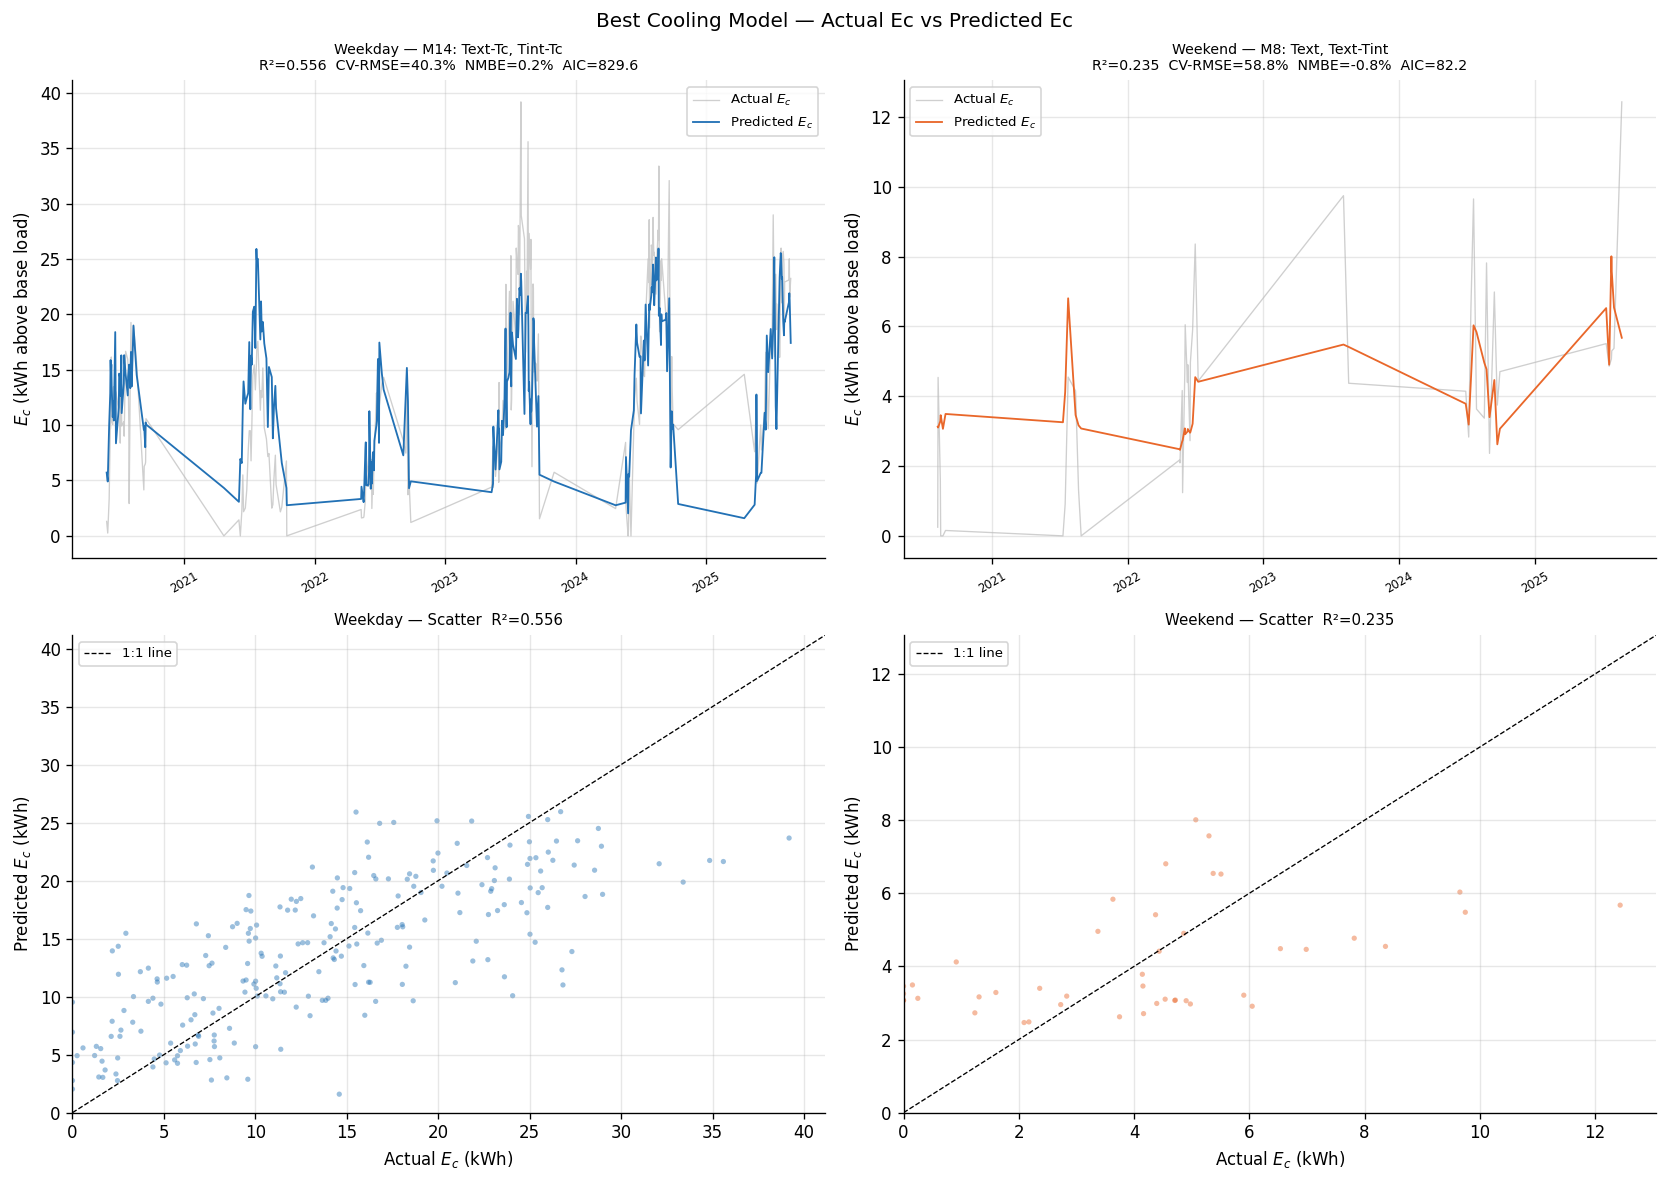

Saved: cooling_best_model_actual_vs_pred.png


In [247]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Best Cooling Model — Actual Ec vs Predicted Ec', fontsize=12)

for col_idx, day_type in enumerate(['weekday', 'weekend']):
    if day_type not in best_models or day_type not in cooling_31_results:
        for row_i in range(2):
            axes[row_i, col_idx].set_visible(False)
        continue

    bm_no  = int(best_models[day_type]['Model'])
    bm_rec = cooling_31_results[day_type][bm_no - 1]

    Ec_actual = bm_rec['Ec_actual']
    Ec_pred   = bm_rec['Ec_pred']
    col       = COLORS[day_type]

    sub_cool, _, _, _ = get_cooling_subset(df, YEAR_KEY, day_type)
    dates = sub_cool['datetime'].values

    # ── Time series ──────────────────────────────────────────────────────────
    ax_ts = axes[0, col_idx]
    ax_ts.plot(dates, Ec_actual,
               color=COLORS[f'actual_{day_type[:2]}'], lw=0.8, alpha=0.7,
               label='Actual $E_c$')
    ax_ts.plot(dates, Ec_pred, color=col, lw=1.1,
               label='Predicted $E_c$')
    ax_ts.set_title(
        f'{day_type.capitalize()} — M{bm_no}: {bm_rec["variables"]}\n'
        f'R²={bm_rec["R2"]:.3f}  CV-RMSE={bm_rec["CV_RMSE_pct"]:.1f}%  '
        f'NMBE={bm_rec["NMBE_pct"]:.1f}%  AIC={bm_rec["AIC"]:.1f}',
        fontsize=8.5
    )
    ax_ts.set_ylabel('$E_c$ (kWh above base load)')
    ax_ts.legend(fontsize=8)
    ax_ts.tick_params(axis='x', rotation=30, labelsize=7)

    # ── Scatter ──────────────────────────────────────────────────────────────
    ax_sc = axes[1, col_idx]
    ax_sc.scatter(Ec_actual, Ec_pred, s=10, alpha=0.45, color=col, edgecolors='none')
    lo = min(Ec_actual.min(), Ec_pred.min()) * 0.95
    hi = max(Ec_actual.max(), Ec_pred.max()) * 1.05
    ax_sc.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='1:1 line')
    ax_sc.set_xlim(lo, hi); ax_sc.set_ylim(lo, hi)
    ax_sc.set_xlabel('Actual $E_c$ (kWh)')
    ax_sc.set_ylabel('Predicted $E_c$ (kWh)')
    ax_sc.set_title(f'{day_type.capitalize()} — Scatter  R²={bm_rec["R2"]:.3f}', fontsize=9)
    ax_sc.legend(fontsize=8)

plt.tight_layout()
plt.savefig('cooling_best_model_actual_vs_pred.png', bbox_inches='tight')
plt.show()
print('Saved: cooling_best_model_actual_vs_pred.png')


## 12 · Coefficient profile across all 31 models

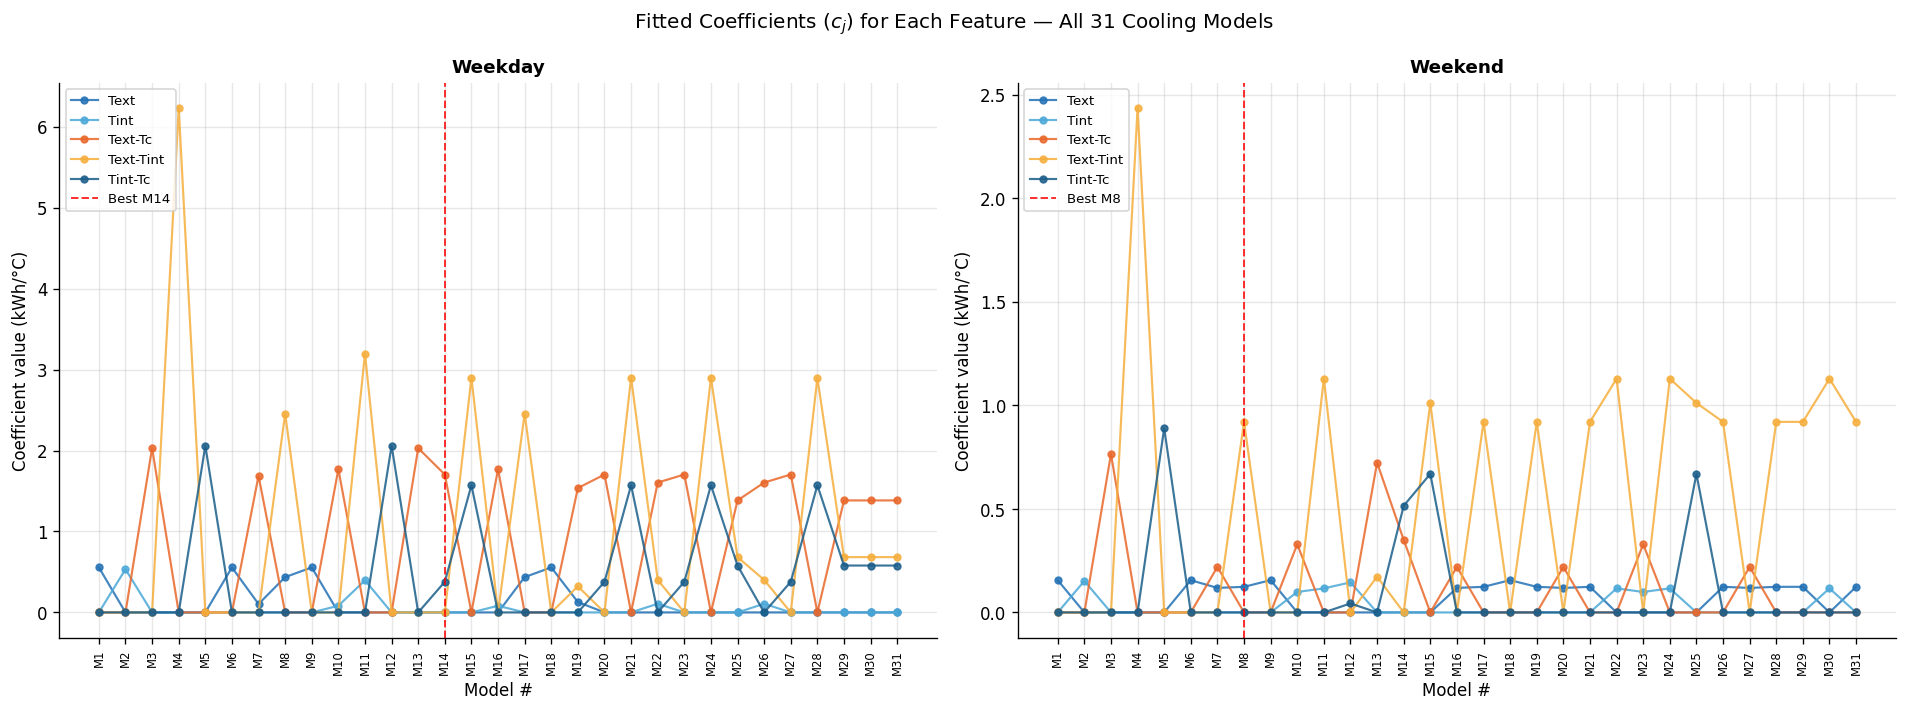

Saved: cooling_31models_coeff_profile.png


In [248]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fitted Coefficients ($c_j$) for Each Feature — All 31 Cooling Models',
             fontsize=12)

feat_colors = {
    'Text'     : '#2271B5',
    'Tint'     : '#4AA8D8',
    'Text-Tc'  : '#E9672A',
    'Text-Tint': '#F5AE3C',
    'Tint-Tc'  : '#1B5E8A',
}

for ax, day_type in zip(axes, ['weekday', 'weekend']):
    if day_type not in summary_dfs:
        ax.set_visible(False); continue

    ok    = summary_dfs[day_type][summary_dfs[day_type]['Status'] == 'OK'].sort_values('Model')
    x_pos = np.arange(len(ok))

    for feat, fc in feat_colors.items():
        vals = ok[feat].fillna(0).values
        ax.plot(x_pos, vals, marker='o', ms=4, lw=1.3, color=fc, alpha=0.85, label=feat)

    # Mark best model with vertical line
    if day_type in best_models:
        bm_no = int(best_models[day_type]['Model'])
        model_list = ok['Model'].tolist()
        if bm_no in model_list:
            pos = model_list.index(bm_no)
            ax.axvline(pos, ls='--', color='red', lw=1.2, alpha=0.8,
                       label=f'Best M{bm_no}')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'M{int(m)}' for m in ok['Model']], rotation=90, fontsize=7)
    ax.set_xlabel('Model #')
    ax.set_ylabel('Coefficient value (kWh/°C)')
    ax.set_title(day_type.capitalize(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('cooling_31models_coeff_profile.png', bbox_inches='tight')
plt.show()
print('Saved: cooling_31models_coeff_profile.png')


## 13 · Per-year loop — all 31 cooling models

Repeats the full 31-model fitting for every *(year, day_type)* pair found in `cp_params`.
Results are collected in `per_year_df` for export and ranking.


In [249]:
loop_pairs = cp[cp['year'] != 'all'][['year','day_type']].drop_duplicates()

per_year_records = []

for _, row_cp in loop_pairs.iterrows():
    yr       = row_cp['year']
    day_type = row_cp['day_type']

    try:
        Tc_l, Th_l, Eb_l = get_cp(yr, day_type)
    except Exception as e:
        print(f'  {yr}/{day_type}: skipped — {e}'); continue

    sub_l      = get_subset(df, yr, day_type)
    cool_mask  = (sub_l['temp_external'] > Tc_l) & (sub_l['electricity_kWh'] > Eb_l)
    sub_cool_l = sub_l[cool_mask].reset_index(drop=True)

    if len(sub_cool_l) < 3:
        print(f'  {yr}/{day_type}: skipped — only {len(sub_cool_l)} cooling rows')
        continue

    T_ext_l  = sub_cool_l['temp_external'].values
    T_int_l  = sub_cool_l['temp_internal'].values
    Ec_act_l = np.maximum(sub_cool_l['electricity_kWh'].values - Eb_l, 0)
    n_l      = len(Ec_act_l)
    Xall_l   = build_feature_matrix(T_ext_l, T_int_l, Tc_l, Th_l)

    for model_no, combo in enumerate(ALL_COMBOS, 1):
        k         = len(combo)
        var_names = [FEATURE_LABELS[j] for j in combo]
        X_sub_l   = Xall_l[list(combo), :]

        def make_m(Xf):
            def _m(_, *c): return sum(ci * Xf[i] for i, ci in enumerate(c))
            return _m

        try:
            popt_l, _ = curve_fit(
                make_m(X_sub_l), np.zeros(n_l), Ec_act_l,
                p0=[1.0]*k, bounds=(0, np.inf),
                method='trf', maxfev=20000
            )
            Ec_pred_l = make_m(X_sub_l)(None, *popt_l)
            mets_l    = compute_metrics(Ec_act_l, Ec_pred_l, k)
            status_l  = 'OK'
            coeffs_l  = {var_names[i]: round(float(popt_l[i]), 6) for i in range(k)}
        except Exception as ex:
            mets_l   = {m: np.nan for m in
                        ['R2','Adj_R2','RMSE','CV_RMSE_pct','NMBE_pct','AIC','BIC','n_params']}
            status_l = f'FAILED: {ex}'
            coeffs_l = {v: np.nan for v in var_names}

        per_year_records.append(dict(
            year=int(yr), day_type=day_type,
            model_no=model_no, n_vars=k,
            variables=', '.join(var_names),
            n=n_l, Tc=Tc_l, Eb=Eb_l,
            status=status_l,
            **coeffs_l,
            **mets_l,
        ))

per_year_df = pd.DataFrame(per_year_records)
n_ok = (per_year_df['status'] == 'OK').sum()
print(f'Per-year fits completed: {len(per_year_df)}  |  successful: {n_ok}')
display(
    per_year_df[per_year_df['status']=='OK']
    [['year','day_type','model_no','n_vars','variables','R2','CV_RMSE_pct','NMBE_pct','AIC']]
    .sort_values(['year','day_type','AIC'])
    .head(30)
    .round(4)
)


  2023/weekend: skipped — only 2 cooling rows
Per-year fits completed: 341  |  successful: 341


,year,day_type,model_no,n_vars,variables,R2,CV_RMSE_pct,NMBE_pct,AIC
13,2020,weekday,14,2,"Text-Tc, Tint-Tc",0.4409,27.7039,0.6983,93.0335
22,2020,weekday,23,3,"Tint, Text-Tc, Tint-Tc",0.4409,27.7039,0.6983,95.0335
19,2020,weekday,20,3,"Text, Text-Tc, Tint-Tc",0.4409,27.7039,0.6983,95.0335
24,2020,weekday,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.4409,27.7039,0.6983,95.0335
9,2020,weekday,10,2,"Tint, Text-Tc",0.4090,28.4849,0.1891,95.0353
6,2020,weekday,7,2,"Text, Text-Tc",0.3997,28.7068,0.0000,95.5939
26,2020,weekday,27,4,"Text, Tint, Text-Tc, Tint-Tc",0.4409,27.7039,0.6983,97.0335
28,2020,weekday,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.4409,27.7039,0.6983,97.0335
29,2020,weekday,30,4,"Tint, Text-Tc, Text-Tint, Tint-Tc",0.4409,27.7039,0.6983,97.0335
15,2020,weekday,16,3,"Text, Tint, Text-Tc",0.4090,28.4849,0.1891,97.0353


## 14 · Per-year best cooling model selection

In [250]:
best_per_year = []

for (yr, dt), grp in per_year_df.groupby(['year', 'day_type']):
    ok = grp[grp['status'] == 'OK'].sort_values('AIC').reset_index(drop=True)
    if ok.empty: continue

    delta_aic  = ok['AIC'] - ok['AIC'].iloc[0]
    comparable = ok[delta_aic < 2]
    best       = comparable.sort_values(['n_vars', 'AIC']).iloc[0]

    best_per_year.append({
        'year'         : yr,
        'day_type'     : dt,
        'best_model_no': int(best['model_no']),
        'n_vars'       : int(best['n_vars']),
        'variables'    : best['variables'],
        'R2'           : best['R2'],
        'AIC'          : best['AIC'],
        'CV_RMSE_pct'  : best['CV_RMSE_pct'],
        'NMBE_pct'     : best['NMBE_pct'],
        'ASHRAE_pass'  : bool(best['CV_RMSE_pct'] <= 25 and abs(best['NMBE_pct']) <= 5),
    })

best_yr_df = pd.DataFrame(best_per_year)
print('Best cooling model per year / day_type  (AIC + parsimony selection):')
display(best_yr_df.sort_values(['year','day_type']).round(4))


Best cooling model per year / day_type  (AIC + parsimony selection):


,year,day_type,best_model_no,n_vars,variables,R2,AIC,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
0,2020,weekday,14,2,"Text-Tc, Tint-Tc",0.4409,93.0335,27.7039,0.6983,False
1,2020,weekend,2,1,Tint,-0.0339,8.8726,71.1458,-0.8520,False
2,2021,weekday,3,1,Text-Tc,0.7891,66.4215,26.7646,-0.4919,False
3,2021,weekend,1,1,Text,0.2060,8.9930,47.5365,2.4317,False
4,2022,weekday,3,1,Text-Tc,0.4865,74.3902,50.1148,-6.6938,False
5,2022,weekend,3,1,Text-Tc,0.3998,11.3388,38.6366,-7.8165,False
6,2023,weekday,14,2,"Text-Tc, Tint-Tc",0.5241,206.5216,35.3598,1.5461,False
7,2024,weekday,3,1,Text-Tc,0.7061,146.0628,25.5017,-2.2801,False
8,2024,weekend,11,2,"Tint, Text-Tint",0.3537,16.7897,45.4251,-1.2400,False
9,2025,weekday,14,2,"Text-Tc, Tint-Tc",0.5006,105.8569,32.8922,1.0458,False


## 15 · Per-year R² heatmap — best cooling model

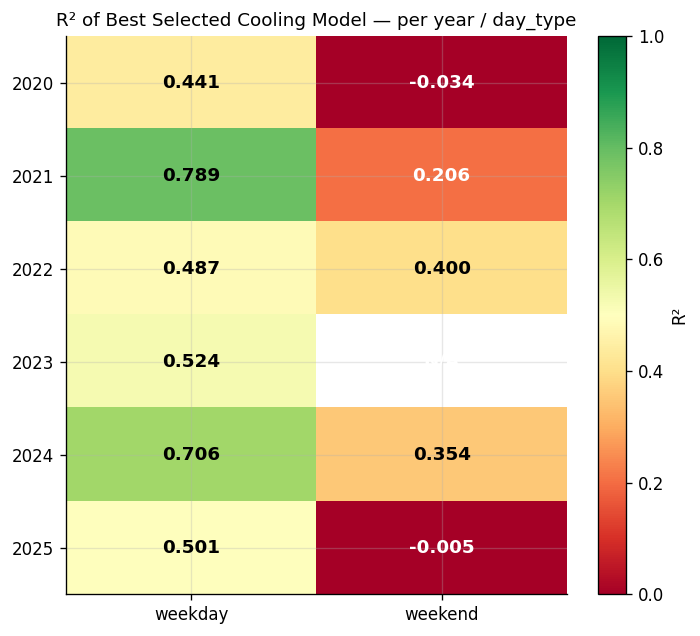

Saved: cooling_per_year_best_r2_heatmap.png


In [251]:
if not best_yr_df.empty:
    pivot_r2 = best_yr_df.pivot_table(index='year', columns='day_type', values='R2')

    h = max(4, len(pivot_r2) * 0.65 + 1.5)
    w = max(5, len(pivot_r2.columns) * 3)
    fig, ax = plt.subplots(figsize=(w, h))

    im = ax.imshow(pivot_r2.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, label='R²')

    ax.set_xticks(range(len(pivot_r2.columns)))
    ax.set_xticklabels(pivot_r2.columns, fontsize=10)
    ax.set_yticks(range(len(pivot_r2.index)))
    ax.set_yticklabels(pivot_r2.index, fontsize=10)
    ax.set_title('R² of Best Selected Cooling Model — per year / day_type', fontsize=11)

    for i in range(len(pivot_r2.index)):
        for j in range(len(pivot_r2.columns)):
            val = pivot_r2.values[i, j]
            txt = f'{val:.3f}' if not np.isnan(val) else 'N/A'
            fg  = 'black' if 0.3 < val < 0.8 else 'white'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=11, color=fg, fontweight='bold')

    plt.tight_layout()
    plt.savefig('cooling_per_year_best_r2_heatmap.png', bbox_inches='tight')
    plt.show()
    print('Saved: cooling_per_year_best_r2_heatmap.png')


## 16 · Export results

In [252]:
# ═══════════════════════════════════════════════════════════════════════════
# CSV 1 — All individual years 2020-2025 (weekday + weekend where available)
#          Source: per-year loop (Section 13)
# ═══════════════════════════════════════════════════════════════════════════
if not per_year_df.empty:
    csv1 = per_year_df.copy()
    csv1 = csv1.sort_values(['year', 'day_type', 'model_no']).reset_index(drop=True)
    csv1.to_csv('cooling_31models_2020_2025.csv', index=False)
    print(f'Saved: cooling_31models_2020_2025.csv')
    print(f'  years    : {sorted(csv1["year"].unique())}')
    print(f'  day_types: {sorted(csv1["day_type"].unique())}')
    print(f'  rows     : {len(csv1)}')
    print()

# ═══════════════════════════════════════════════════════════════════════════
# CSV 2 — Individual years 2021-2024 only (weekday + weekend where available)
#          Source: same per-year loop, filtered
# ═══════════════════════════════════════════════════════════════════════════
if not per_year_df.empty:
    csv2 = per_year_df[per_year_df['year'].isin([2021, 2022, 2023, 2024])].copy()
    csv2 = csv2.sort_values(['year', 'day_type', 'model_no']).reset_index(drop=True)
    csv2.to_csv('cooling_31models_2021_2024.csv', index=False)
    print(f'Saved: cooling_31models_2021_2024.csv')
    print(f'  years    : {sorted(csv2["year"].unique())}')
    print(f'  day_types: {sorted(csv2["day_type"].unique())}')
    print(f'  rows     : {len(csv2)}')
    print()

# ═══════════════════════════════════════════════════════════════════════════
# CSV 3 — Best model per year (2020-2025), both day_types
#          Source: Section 14 best-selection loop
# ═══════════════════════════════════════════════════════════════════════════
if not best_yr_df.empty:
    best_yr_df.to_csv('cooling_31models_best_per_year.csv', index=False)
    print(f'Saved: cooling_31models_best_per_year.csv  ({len(best_yr_df)} rows)')
    print()

# ═══════════════════════════════════════════════════════════════════════════
# CSV 4 — All-years combined (year_key='all'), weekday + weekend in one file
#          Source: all_summary_dfs['all'] (Section 5 main loop)
# ═══════════════════════════════════════════════════════════════════════════
if 'all' in all_summary_dfs:
    frames = []
    for day_type, sdf in all_summary_dfs['all'].items():
        out = sdf.copy()
        out.insert(0, 'day_type', day_type)
        out.insert(0, 'year_key', 'all')
        if 'ASHRAE_pass' not in out.columns:
            out['ASHRAE_pass'] = (
                (out['CV_RMSE_pct'] <= 25) &
                (out['NMBE_pct'].abs() <= 5) &
                (out['Status'] == 'OK')
            )
        frames.append(out)

    if frames:
        csv4 = pd.concat(frames, ignore_index=True)
        csv4 = csv4.sort_values(['day_type', 'Model']).reset_index(drop=True)
        csv4.to_csv('cooling_31models_all_years_combined.csv', index=False)
        print(f'Saved: cooling_31models_all_years_combined.csv')
        print(f'  day_types: {sorted(csv4["day_type"].unique())}')
        print(f'  rows     : {len(csv4)}')
        print()
        for dt in sorted(csv4['day_type'].unique()):
            sub  = csv4[csv4['day_type'] == dt]
            ok   = sub[sub['Status'] == 'OK']
            n_pass = ok['ASHRAE_pass'].sum() if 'ASHRAE_pass' in ok.columns else 0
            print(f'  {dt}: {len(ok)}/31 OK   ASHRAE pass: {n_pass}/31')
            top = ok.sort_values('AIC').head(5)
            if not top.empty:
                print(f'  Top 5 by AIC ({dt}):')
                display(top[['Model','n_vars','Variables','R2','CV_RMSE_pct',
                              'NMBE_pct','AIC','ASHRAE_pass']].round(4))
            print()

# ═══════════════════════════════════════════════════════════════════════════
# Final console summary — best model per year / day_type
# ═══════════════════════════════════════════════════════════════════════════
if not best_yr_df.empty:
    print('Best cooling model selected per year / day_type:')
    display(
        best_yr_df[['year','day_type','best_model_no','n_vars','variables',
                    'R2','CV_RMSE_pct','NMBE_pct','ASHRAE_pass']]
        .sort_values(['year','day_type'])
        .round(4)
    )

Saved: cooling_31models_2020_2025.csv
  years    : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  day_types: ['weekday', 'weekend']
  rows     : 341

Saved: cooling_31models_2021_2024.csv
  years    : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  day_types: ['weekday', 'weekend']
  rows     : 217

Saved: cooling_31models_best_per_year.csv  (11 rows)

Saved: cooling_31models_all_years_combined.csv
  day_types: ['weekday', 'weekend']
  rows     : 62

  weekday: 31/31 OK   ASHRAE pass: 0/31
  Top 5 by AIC (weekday):


,Model,n_vars,Variables,R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
24,25,3,"Text-Tc, Text-Tint, Tint-Tc",0.5598,40.1454,0.4046,829.3987,False
13,14,2,"Text-Tc, Tint-Tc",0.5556,40.3330,0.2195,829.6451,False
9,10,2,"Tint, Text-Tc",0.5537,40.4209,0.0866,830.6953,False
6,7,2,"Text, Text-Tc",0.5530,40.4546,-0.0008,831.0961,False
28,29,4,"Text, Text-Tc, Text-Tint, Tint-Tc",0.5598,40.1454,0.4046,831.3987,False



  weekend: 31/31 OK   ASHRAE pass: 0/31
  Top 5 by AIC (weekend):


,Model,n_vars,Variables,R2,CV_RMSE_pct,NMBE_pct,AIC,ASHRAE_pass
38,8,2,"Text, Text-Tint",0.2347,58.7627,-0.7582,82.2076,False
41,11,2,"Tint, Text-Tint",0.2298,58.9511,-0.7341,82.4892,False
49,19,3,"Text, Text-Tc, Text-Tint",0.2347,58.7627,-0.7582,84.2076,False
47,17,3,"Text, Tint, Text-Tint",0.2347,58.7627,-0.7582,84.2076,False
51,21,3,"Text, Text-Tint, Tint-Tc",0.2347,58.7627,-0.7582,84.2076,False



Best cooling model selected per year / day_type:


,year,day_type,best_model_no,n_vars,variables,R2,CV_RMSE_pct,NMBE_pct,ASHRAE_pass
0,2020,weekday,14,2,"Text-Tc, Tint-Tc",0.4409,27.7039,0.6983,False
1,2020,weekend,2,1,Tint,-0.0339,71.1458,-0.8520,False
2,2021,weekday,3,1,Text-Tc,0.7891,26.7646,-0.4919,False
3,2021,weekend,1,1,Text,0.2060,47.5365,2.4317,False
4,2022,weekday,3,1,Text-Tc,0.4865,50.1148,-6.6938,False
5,2022,weekend,3,1,Text-Tc,0.3998,38.6366,-7.8165,False
6,2023,weekday,14,2,"Text-Tc, Tint-Tc",0.5241,35.3598,1.5461,False
7,2024,weekday,3,1,Text-Tc,0.7061,25.5017,-2.2801,False
8,2024,weekend,11,2,"Tint, Text-Tint",0.3537,45.4251,-1.2400,False
9,2025,weekday,14,2,"Text-Tc, Tint-Tc",0.5006,32.8922,1.0458,False
